# **Analysis international football result from 1872 to 2026**

Este conjunto de datos incluye **49.016** resultados de partidos internacionales de fútbol desde el primer partido oficial en 1872 hasta 2025. Los partidos incluyen Copa Mundial de la FIFA, torneos continentales y amistosos. Los datos son partidos internacionales masculinos completos y no incluyen Juegos Olímpicos ni partidos con equipos B o selecciones sub-23.

### **Archivos del dataset**

**results.csv**: contiene columnas como `date`, `home_team`, `away_team`, `home_score`, `away_score`, `tournament`, `city`, `country`, `neutral`.

**shootouts.csv**: columnas principales `date`, `home_team`, `away_team`, `winner`, `first_shooter`.

**goalscorers.csv**: columnas principales `date`, `home_team`, `away_team`, `team`, `scorer`, `own_goal`, `penalty`.

**former_names.csv**: columnas `current`, `former`, `start_date`, `end_date`.


# Taller Pandas

1. Formula al menos 3 preguntas de análisis sobre tu conjunto de datos.
2. Utilizando Pandas: limpieza (dropna, fillna, replace), filtrado y selección, transformaciones y agrupaciones (groupby).

3. Responde las preguntas planteadas con una breve interpretación.

### Preguntas:
- ¿Cuál es Top 15 equipos en la historia con mejor win rate(% de victoria) (>= 20 partidos) ?
- ¿Qué torneos han tenido más goles por partido en los últimos 5 años?
- ¿Cuál es el Top 20 de Jugadores con mayor marcador de goles en diferentes torneos durante los últimos 5 años?


### Explorar Datos


In [2]:
import pandas as pd
import numpy as np
from pathlib import Path

In [3]:

csv_path = Path('..') / 'Dataset' 
former_date = pd.read_csv(csv_path/ 'former_names.csv')
former_date.head()

,current,former,start_date,end_date
0,Benin,Dahomey,1959-11-08,1975-11-30
1,Burkina Faso,Upper Volta,1960-04-14,1984-08-04
2,Curaçao,Netherlands Antilles,1957-03-03,2010-10-10
3,Czechoslovakia,Bohemia,1903-04-05,1919-01-01
4,Czechoslovakia,Bohemia and Moravia,1939-01-01,1945-05-01


In [4]:
goals = pd.read_csv(csv_path/'goalscorers.csv')
goals.head()

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False


In [5]:
results =  pd.read_csv(csv_path/'results.csv')
results.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0.0,0.0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4.0,2.0,Friendly,London,England,False
2,1874-03-07,Scotland,England,2.0,1.0,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2.0,2.0,Friendly,London,England,False
4,1876-03-04,Scotland,England,3.0,0.0,Friendly,Glasgow,Scotland,False


In [6]:
shootouts = pd.read_csv(csv_path/'shootouts.csv')
shootouts.head()

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN


### Limpieza de datos (Pandas: dropna, fillna, replace, etc.)

Validación de nulos del dataframe `results`

In [7]:
results.isnull().sum()

date           0
home_team      0
away_team      0
home_score    72
away_score    72
tournament     0
city           0
country        0
neutral        0
dtype: int64

In [8]:
results_null_scores = results[
    results['home_score'].isna() | results['away_score'].isna()
]
results_null_scores

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
49215,2026-06-11,Mexico,South Africa,NaN,NaN,FIFA World Cup,Mexico City,Mexico,False
49216,2026-06-11,South Korea,Czech Republic,NaN,NaN,FIFA World Cup,Zapopan,Mexico,True
49217,2026-06-12,Canada,Bosnia and Herzegovina,NaN,NaN,FIFA World Cup,Toronto,Canada,False
49218,2026-06-12,United States,Paraguay,NaN,NaN,FIFA World Cup,Inglewood,United States,False
49219,2026-06-13,Qatar,Switzerland,NaN,NaN,FIFA World Cup,Santa Clara,United States,True
...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,NaN,NaN,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,NaN,NaN,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,NaN,NaN,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,NaN,NaN,FIFA World Cup,East Rutherford,United States,True


Remplazar los NA por 0 en dataframe `results`

In [9]:
# Reemplazar NaN en home_score y away_score por 0
results[['home_score', 'away_score']] = results[['home_score', 'away_score']].fillna(0)
results_clean = results.copy()
# Asegurar que las columnas de score sean numéricas para permitir comparaciones >
results_clean['home_score'] = pd.to_numeric(results_clean['home_score'], errors='coerce').fillna(0).astype(int)
results_clean['away_score'] = pd.to_numeric(results_clean['away_score'], errors='coerce').fillna(0).astype(int)
results_clean.isnull().sum()

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64

Cambiar el formato de fecha del dataframe `results`

In [10]:
# Convertir la columna date de forma segura; valores inválidos -> NaT
results_clean['date'] = pd.to_datetime(results_clean['date'])

Detalles del dataframe final `results_f`

In [11]:
results_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49287 entries, 0 to 49286
Data columns (total 9 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        49287 non-null  datetime64[ns]
 1   home_team   49287 non-null  object        
 2   away_team   49287 non-null  object        
 3   home_score  49287 non-null  int64         
 4   away_score  49287 non-null  int64         
 5   tournament  49287 non-null  object        
 6   city        49287 non-null  object        
 7   country     49287 non-null  object        
 8   neutral     49287 non-null  bool          
dtypes: bool(1), datetime64[ns](1), int64(2), object(5)
memory usage: 3.1+ MB


In [12]:
results_clean.describe()

,date,home_score,away_score
count,49287,49287.000000,49287.000000
mean,1994-04-13 22:21:42.915576064,1.753525,1.180676
min,1872-11-30 00:00:00,0.000000,0.000000
25%,1980-07-27 00:00:00,1.000000,0.000000
50%,2000-06-18 00:00:00,1.000000,1.000000
75%,2013-06-08 00:00:00,2.000000,2.000000
max,2026-06-27 00:00:00,31.000000,21.000000
std,NaN,1.770594,1.401474


Validación de nulos del dataframe `goals`

In [13]:
goals.isnull().sum()

date           0
home_team      0
away_team      0
team           0
scorer        48
minute       256
own_goal       0
penalty        0
dtype: int64

In [14]:
goals_null_scores = goals[
    goals['scorer'].isna() & goals['minute'].isna()
]
goals_null_scores

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
8697,1980-02-24,Vanuatu,Papua New Guinea,Papua New Guinea,NaN,NaN,False,False
8698,1980-02-24,Vanuatu,Papua New Guinea,Papua New Guinea,NaN,NaN,False,False
8699,1980-02-24,Vanuatu,Papua New Guinea,Papua New Guinea,NaN,NaN,False,False
8700,1980-02-24,Vanuatu,Papua New Guinea,Papua New Guinea,NaN,NaN,False,False
8701,1980-02-24,Vanuatu,Papua New Guinea,Vanuatu,NaN,NaN,False,False
8702,1980-02-24,Vanuatu,Papua New Guinea,Vanuatu,NaN,NaN,False,False
8703,1980-02-24,Vanuatu,Papua New Guinea,Vanuatu,NaN,NaN,False,False
8704,1980-02-25,Fiji,Solomon Islands,Fiji,NaN,NaN,False,False
8705,1980-02-25,Fiji,Solomon Islands,Fiji,NaN,NaN,False,False
8706,1980-02-25,Fiji,Solomon Islands,Fiji,NaN,NaN,False,False


In [15]:
goals_null_scores.count()

date         48
home_team    48
away_team    48
team         48
scorer        0
minute        0
own_goal     48
penalty      48
dtype: int64

Eliminar nulos del dataframe `goals`

In [20]:
goals_clean = goals.dropna(subset=['scorer', 'minute']).copy()
goals_clean.isnull().sum()

date         0
home_team    0
away_team    0
team         0
scorer       0
minute       0
own_goal     0
penalty      0
dtype: int64

In [17]:
goals_null_scores_2 = goals_clean[
    goals_clean['scorer'].isna() | goals_clean['minute'].isna()
]
goals_null_scores_2

,date,home_team,away_team,team,scorer,minute,own_goal,penalty


In [18]:
goals_clean[['minute']] = goals_clean[['minute']].fillna(-1)


Cambiar el formato de `date` del dataframe `goals_f`

In [23]:
goals_clean['date'] = pd.to_datetime(goals_clean['date'])
goals_clean

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
47596,2026-03-31,Sweden,Poland,Sweden,Anthony Elanga,20.0,False,False
47597,2026-03-31,Sweden,Poland,Poland,Nicola Zalewski,33.0,False,False
47598,2026-03-31,Sweden,Poland,Sweden,Gustaf Lagerbielke,44.0,False,False
47599,2026-03-31,Sweden,Poland,Poland,Karol Świderski,55.0,False,False


Detalles del dataframe final `goals_f`

In [24]:
goals_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47345 entries, 0 to 47600
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype         
---  ------     --------------  -----         
 0   date       47345 non-null  datetime64[ns]
 1   home_team  47345 non-null  object        
 2   away_team  47345 non-null  object        
 3   team       47345 non-null  object        
 4   scorer     47345 non-null  object        
 5   minute     47345 non-null  float64       
 6   own_goal   47345 non-null  bool          
 7   penalty    47345 non-null  bool          
dtypes: bool(2), datetime64[ns](1), float64(1), object(4)
memory usage: 2.6+ MB


In [25]:
goals_clean.describe()

,date,minute
count,47345,47345.000000
mean,1999-05-29 19:06:49.766606848,50.047397
min,1916-07-02 00:00:00,1.000000
25%,1989-06-04 00:00:00,28.000000
50%,2004-06-20 00:00:00,51.000000
75%,2016-06-05 00:00:00,73.000000
max,2026-03-31 00:00:00,122.000000
std,NaN,26.363283


Validación de nulos del dataframe `shootouts`

In [26]:
shootouts.isnull().sum()

date               0
home_team          0
away_team          0
winner             0
first_shooter    429
dtype: int64

In [27]:
shootouts_null_scores = shootouts[
    shootouts['first_shooter'].isna()
]
shootouts_null_scores

,date,home_team,away_team,winner,first_shooter
0,1967-08-22,India,Taiwan,Taiwan,NaN
1,1971-11-14,South Korea,Vietnam Republic,South Korea,NaN
2,1972-05-07,South Korea,Iraq,Iraq,NaN
3,1972-05-17,Thailand,South Korea,South Korea,NaN
4,1972-05-19,Thailand,Cambodia,Thailand,NaN
...,...,...,...,...,...
661,2025-12-12,Algeria,United Arab Emirates,United Arab Emirates,NaN
668,2026-03-28,Namibia,Comoros,Namibia,NaN
669,2026-03-30,Azerbaijan,Sierra Leone,Azerbaijan,NaN
671,2026-03-30,Gabon,Trinidad and Tobago,Gabon,NaN


Conteo del dataframe `shootouts`

In [28]:
shootouts.count()

date             675
home_team        675
away_team        675
winner           675
first_shooter    246
dtype: int64

Asignar `UNKNOWN` a valores nulos en `first_shooter` en `shootouts`

In [29]:
shootouts['first_shooter'] = shootouts['first_shooter'].fillna('UNKNOWN')

Cambiar formato de `date` en el dataframe `shootouts`

In [30]:
shootouts['date'] = pd.to_datetime(shootouts['date'])

Verificación de detalles del dataframe `shootouts`

In [31]:
shootouts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 675 entries, 0 to 674
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           675 non-null    datetime64[ns]
 1   home_team      675 non-null    object        
 2   away_team      675 non-null    object        
 3   winner         675 non-null    object        
 4   first_shooter  675 non-null    object        
dtypes: datetime64[ns](1), object(4)
memory usage: 26.5+ KB


In [32]:
shootouts.describe()

,date
count,675
mean,2004-02-19 20:33:03.999999872
min,1967-08-22 00:00:00
25%,1992-12-24 12:00:00
50%,2004-06-23 00:00:00
75%,2017-06-19 00:00:00
max,2026-03-31 00:00:00


Former names: comprobaciones y parseo de fechas
Verificamos nulos y tipos antes de convertir fechas

In [33]:
former_date.isnull().sum()

current       0
former        0
start_date    0
end_date      0
dtype: int64

In [34]:
former_date.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36 entries, 0 to 35
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   current     36 non-null     object
 1   former      36 non-null     object
 2   start_date  36 non-null     object
 3   end_date    36 non-null     object
dtypes: object(4)
memory usage: 1.3+ KB


In [36]:
former_date['start_date'] = pd.to_datetime(former_date['start_date'])
former_date['end_date'] = pd.to_datetime(former_date['end_date'])

In [37]:
former_date.describe()

,start_date,end_date
count,36,36
mean,1951-11-09 16:00:00,1974-08-24 02:00:00
min,1882-02-18 00:00:00,1919-01-01 00:00:00
25%,1938-07-02 12:00:00,1962-01-04 12:00:00
50%,1951-12-24 00:00:00,1973-01-22 00:00:00
75%,1963-09-18 12:00:00,1992-01-06 12:00:00
max,2003-02-04 00:00:00,2018-11-19 00:00:00


In [38]:
print(results_clean.isnull().sum())
print(goals_clean.isnull().sum())
print(shootouts.isnull().sum())

date          0
home_team     0
away_team     0
home_score    0
away_score    0
tournament    0
city          0
country       0
neutral       0
dtype: int64
date         0
home_team    0
away_team    0
team         0
scorer       0
minute       0
own_goal     0
penalty      0
dtype: int64
date             0
home_team        0
away_team        0
winner           0
first_shooter    0
dtype: int64


Validación de duplicados

In [39]:
results_clean.duplicated(subset=['date','home_team','away_team']).sum()

np.int64(1)

In [40]:
results_f = results_clean.drop_duplicates(subset=['date','home_team','away_team'],  keep='first')

In [41]:
results_f

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False
...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,0,0,FIFA World Cup,Arlington,United States,True
49283,2026-06-27,Colombia,Portugal,0,0,FIFA World Cup,Miami Gardens,United States,True
49284,2026-06-27,DR Congo,Uzbekistan,0,0,FIFA World Cup,Atlanta,United States,True
49285,2026-06-27,Panama,England,0,0,FIFA World Cup,East Rutherford,United States,True


In [42]:
shootouts.duplicated(subset=['date','home_team','away_team']).sum()

np.int64(0)

In [43]:
shootouts[shootouts.duplicated(subset=['date','home_team','away_team'], keep=False)]

,date,home_team,away_team,winner,first_shooter


In [49]:
goals_clean.duplicated().sum()

np.int64(10)

In [57]:
goals_clean.count()

date         47345
home_team    47345
away_team    47345
team         47345
scorer       47345
minute       47345
own_goal     47345
penalty      47345
dtype: int64

In [52]:
goals_clean[goals_clean.duplicated(subset=['date','home_team','away_team','team','scorer','minute','own_goal','penalty'], keep=False)]

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
9344,1981-06-06,Fiji,Taiwan,Fiji,Ratu Jone,55.0,False,False
9345,1981-06-06,Fiji,Taiwan,Fiji,Ratu Jone,55.0,False,False
21014,2001-04-30,Oman,Laos,Oman,Hani Al-Dhabit,45.0,False,False
21015,2001-04-30,Oman,Laos,Oman,Hani Al-Dhabit,45.0,False,False
22148,2002-01-30,Burkina Faso,Ghana,Ghana,Isaac Boakye,90.0,False,False
22149,2002-01-30,Burkina Faso,Ghana,Ghana,Isaac Boakye,90.0,False,False
23267,2003-12-03,Maldives,Mongolia,Maldives,Ibrahim Fazeel,45.0,False,False
23268,2003-12-03,Maldives,Mongolia,Maldives,Ibrahim Fazeel,45.0,False,False
24630,2004-10-09,Turkey,Kazakhstan,Turkey,Fatih Tekke,90.0,False,False
24631,2004-10-09,Turkey,Kazakhstan,Turkey,Fatih Tekke,90.0,False,False


In [56]:
goals_f = goals_clean.drop_duplicates(subset=['date','home_team','away_team','team','scorer','minute','own_goal','penalty'], keep='first')
goals_f

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
0,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,44.0,False,False
1,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,55.0,False,False
2,1916-07-02,Chile,Uruguay,Uruguay,Isabelino Gradín,70.0,False,False
3,1916-07-02,Chile,Uruguay,Uruguay,José Piendibene,75.0,False,False
4,1916-07-06,Argentina,Chile,Argentina,Alberto Ohaco,2.0,False,False
...,...,...,...,...,...,...,...,...
47596,2026-03-31,Sweden,Poland,Sweden,Anthony Elanga,20.0,False,False
47597,2026-03-31,Sweden,Poland,Poland,Nicola Zalewski,33.0,False,False
47598,2026-03-31,Sweden,Poland,Sweden,Gustaf Lagerbielke,44.0,False,False
47599,2026-03-31,Sweden,Poland,Poland,Karol Świderski,55.0,False,False


In [58]:
print('Datos disponibles:')
print(f' - resultados: {len(results_f)}')
print(f' - goles en goals_f: {len(goals_f)}')
print(f' - shootouts: {len(shootouts)}')
print(f' - nombres históricos con former_date: {former_date[former_date["former"].notna()].shape[0]}')


Datos disponibles:
 - resultados: 49286
 - goles en goals_f: 47335
 - shootouts: 675
 - nombres históricos con former_date: 36


### **Pregunta 1: ¿Cuál es Top 15 equipos en la historia con mejor win rate(% de victoria) (>= 20 partidos) ?**

In [59]:
name_map = dict(former_date.dropna(subset=['former'])[['former', 'current']].values)
name_map

{'Dahomey': 'Benin',
 'Upper Volta': 'Burkina Faso',
 'Netherlands Antilles': 'Curaçao',
 'Bohemia': 'Czechoslovakia',
 'Bohemia and Moravia': 'Czechoslovakia',
 'Representation of Czechs and Slovaks': 'Czechoslovakia',
 'Belgian Congo': 'DR Congo',
 'Congo-Léopoldville': 'DR Congo',
 'Congo-Kinshasa': 'DR Congo',
 'Zaïre': 'DR Congo',
 'French Somaliland': 'Djibouti',
 'United Arab Republic': 'Egypt',
 'Swaziland': 'Eswatini',
 'Gold Coast': 'Ghana',
 'Portuguese Guinea': 'Guinea-Bissau',
 'British Guiana': 'Guyana',
 'Dutch East Indies': 'Indonesia',
 'Mandatory Palestine': 'Israel',
 'Nyasaland': 'Malawi',
 'Malaya': 'Malaysia',
 'Burma': 'Myanmar',
 'Macedonia': 'North Macedonia',
 'Ireland': 'Northern Ireland',
 'Irish Free State': 'Republic of Ireland',
 'Éire': 'Republic of Ireland',
 'Soviet Union': 'Russia',
 'CIS': 'Russia',
 'Western Samoa': 'Samoa',
 'FR Yugoslavia': 'Serbia',
 'Serbia and Montenegro': 'Serbia',
 'Ceylon': 'Sri Lanka',
 'Dutch Guyana': 'Suriname',
 'Tangany

##### Normlizar nombre de los equipos con el diccionario name_map haciendo una copia de result_f

In [60]:
results_norm = results_f.copy()
results_norm['home_team'] = results_norm['home_team'].replace(name_map)
results_norm['away_team'] = results_norm['away_team'].replace(name_map)
results_norm.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral
0,1872-11-30,Scotland,England,0,0,Friendly,Glasgow,Scotland,False
1,1873-03-08,England,Scotland,4,2,Friendly,London,England,False
2,1874-03-07,Scotland,England,2,1,Friendly,Glasgow,Scotland,False
3,1875-03-06,England,Scotland,2,2,Friendly,London,England,False
4,1876-03-04,Scotland,England,3,0,Friendly,Glasgow,Scotland,False


#### Conteo y suma cantidad de partidos a total de equipos

In [61]:
home_part = results_norm.groupby('home_team').size()
away_part = results_norm.groupby('away_team').size()
away_part.sort_values(ascending=False).head()

away_team
Uruguay     584
Sweden      568
England     541
Hungary     507
Paraguay    497
dtype: int64

In [62]:
total_part = home_part.add(away_part, fill_value=0)
total_part.sort_values(ascending=False).head()

Sweden       1102.0
England      1091.0
Argentina    1067.0
Brazil       1060.0
Germany      1032.0
dtype: float64

#### Victorias acumuladas por equipo

In [63]:
home_wins = results_norm[results_norm['home_score'] > results_norm['away_score']].groupby('home_team').size()
away_wins = results_norm[results_norm['away_score'] > results_norm['home_score']].groupby('away_team').size() 
wins = home_wins.add(away_wins, fill_value=0)
wins.sort_values(ascending=False).head()

Brazil       670.0
England      623.0
Germany      597.0
Argentina    588.0
Sweden       541.0
dtype: float64

Calcular win rate

In [64]:
win_rate = (wins / total_part * 100).fillna(0)

In [65]:
win_rate_df = pd.DataFrame({
    'num_partidos': total_part.astype(int),
    'wins': wins.reindex(total_part.index).fillna(0).astype(int),
    'win_rate': win_rate
}).sort_values('win_rate', ascending=False)

# Pasar el índice (países) a columna
win_rate_df = win_rate_df.reset_index().rename(columns={'index':'country'})

In [66]:
win_rate_df

,country,num_partidos,wins,win_rate
0,Elba Island,1,1,100.0
1,Asturias,1,1,100.0
2,Surrey,1,1,100.0
3,Maule Sur,2,2,100.0
4,Canary Islands,4,3,75.0
...,...,...,...,...
328,Madrid,1,0,0.0
329,Seborga,1,0,0.0
330,South Yemen,3,0,0.0
331,Găgăuzia,3,0,0.0


In [67]:
min_part = 20

print('\nTop 15 equipos por win rate (>= 20 partidos):')
top15 = (
    win_rate_df[win_rate_df['num_partidos'] >= min_part]
    .sort_values('win_rate', ascending=False)   # ordenar por win_rate
    .head(15))
print(top15)




Top 15 equipos por win rate (>= 20 partidos):
            country  num_partidos  wins   win_rate
6           Padania            44    30  68.181818
11   Basque Country            58    38  65.517241
12           Jersey           235   153  65.106383
13           Brazil          1060   670  63.207547
16         Guernsey           240   145  60.416667
17      Isle of Man            58    35  60.344828
19  Northern Cyprus            34    20  58.823529
20            Spain           784   460  58.673469
22          Germany          1032   597  57.848837
23        Occitania            33    19  57.575758
25          England          1091   623  57.103575
26             Iran           613   347  56.606852
27         Ynys Môn            67    37  55.223881
28        Argentina          1067   588  55.107779
30           Tahiti           241   131  54.356846


### **Conclusiones:**

Distribución de rendimiento general del top 15 de equipos con mejor % de victorias

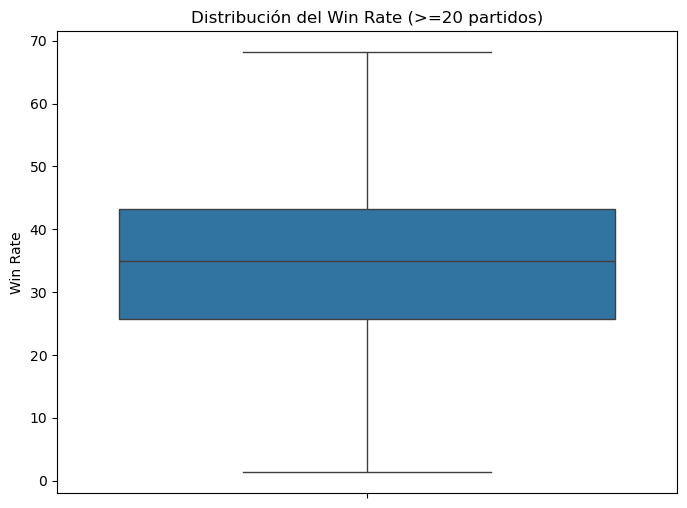

In [68]:
import seaborn as sns
import matplotlib.pyplot as plt

# Filtrar equipos con al menos 20 partidos
filtered = win_rate_df[win_rate_df['num_partidos'] >= 20]

# Crear boxplot del win_rate
plt.figure(figsize=(8,6))
sns.boxplot(y=filtered['win_rate'])
plt.title('Distribución del Win Rate (>=20 partidos)')
plt.ylabel('Win Rate')
plt.show()

El gráfico evidencia cuáles son los equipos más efectivos a nivel de la historia en términos de victorias. Se observa que algunos equipos mantienen un win rate consistentemente alto, lo que refleja su competitividad y regularidad en los partidos.


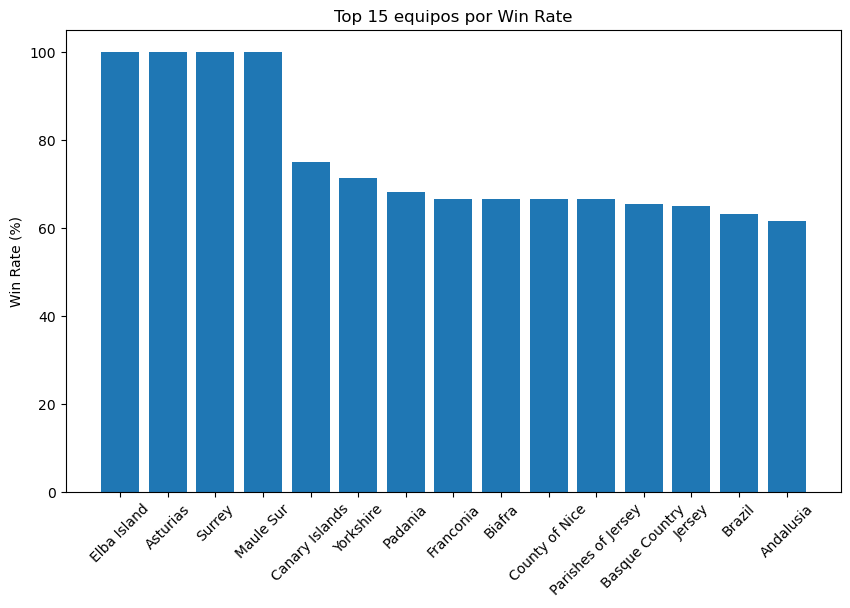

In [69]:
import matplotlib.pyplot as plt

top15 = win_rate_df.head(15)
plt.figure(figsize=(10,6))
plt.bar(top15['country'], top15['win_rate'])
plt.xticks(rotation=45)
plt.ylabel('Win Rate (%)')
plt.title('Top 15 equipos por Win Rate')
plt.show()

Distribución de Win Rate de todos los equipos en general, donde el valor atípico del 100% corresponde a equipos que han ganado todos sus partidos (aunque sean pocos). La mayoría de los equipos tienen un win rate entre el 0% y el 50%, con una mediana alrededor del 20-40%

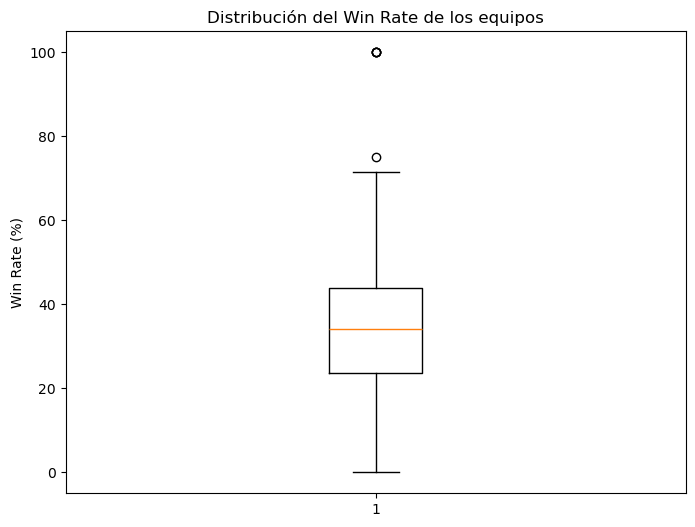

In [70]:
plt.figure(figsize=(8,6))
plt.boxplot(win_rate_df['win_rate'])
plt.ylabel('Win Rate (%)')
plt.title('Distribución del Win Rate de los equipos')
plt.show()

### **Pregunta 2: ¿Qué torneos han tenido más goles por partido en los últimos 5 años?**

Definir rango de los últimos 5 años

In [145]:
ultimos_5y = results_f[results_f['date'] >= '2021-01-01'].copy()
ultimos_5y


,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
43686,2021-01-12,United Arab Emirates,Iraq,0,0,Friendly,Dubai,United Arab Emirates,False,0
43687,2021-01-18,Kuwait,Palestine,0,1,Friendly,Kuwait City,Kuwait,False,1
43688,2021-01-19,Dominican Republic,Puerto Rico,0,1,Friendly,Santo Domingo,Dominican Republic,False,1
43689,2021-01-22,Guatemala,Puerto Rico,1,0,Friendly,Guatemala City,Guatemala,False,1
43690,2021-01-25,Dominican Republic,Serbia,0,0,Friendly,Santo Domingo,Dominican Republic,False,0
...,...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,0,0,FIFA World Cup,Arlington,United States,True,0
49283,2026-06-27,Colombia,Portugal,0,0,FIFA World Cup,Miami Gardens,United States,True,0
49284,2026-06-27,DR Congo,Uzbekistan,0,0,FIFA World Cup,Atlanta,United States,True,0
49285,2026-06-27,Panama,England,0,0,FIFA World Cup,East Rutherford,United States,True,0


Calcular goles por partido

In [146]:
total_goals = ultimos_5y.copy()
total_goals['total_goals'] = total_goals['home_score'] + total_goals['away_score']
total_goals.head()

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
43686,2021-01-12,United Arab Emirates,Iraq,0,0,Friendly,Dubai,United Arab Emirates,False,0
43687,2021-01-18,Kuwait,Palestine,0,1,Friendly,Kuwait City,Kuwait,False,1
43688,2021-01-19,Dominican Republic,Puerto Rico,0,1,Friendly,Santo Domingo,Dominican Republic,False,1
43689,2021-01-22,Guatemala,Puerto Rico,1,0,Friendly,Guatemala City,Guatemala,False,1
43690,2021-01-25,Dominican Republic,Serbia,0,0,Friendly,Santo Domingo,Dominican Republic,False,0


Agrupar por torneo y calcular promedio de goles

In [148]:

goals_per_tournament_5y = (
    ultimos_5y.groupby('tournament')['total_goals']
    .mean()
    .reset_index()
    .rename(columns={'total_goals':'avg_goals_per_match'})
    .sort_values('avg_goals_per_match', ascending=False)
)

print(goals_per_tournament_5y)

                                 tournament  avg_goals_per_match
18  CONIFA World Football Cup qualification                5.600
16                          CONIFA Asia Cup                5.000
53                            Pacific Games                4.625
3            AFF Championship qualification                4.500
63                                Unity Cup                4.000
..                                      ...                  ...
15               CONIFA Africa Football Cup                1.250
45                       Merdeka Tournament                1.250
8                  Al Ain International Cup                1.000
38                      Kirin Challenge Cup                1.000
5          ASEAN Championship qualification                0.500

[64 rows x 2 columns]


In [152]:
goals_per_tournament_5y.count()

tournament             64
avg_goals_per_match    64
dtype: int64

In [153]:
avg_goals_per_tournament_5y = goals_per_tournament_5y[['tournament', 'avg_goals_per_match']].head(10).copy()

In [154]:
avg_goals_per_tournament_5y.count()

tournament             10
avg_goals_per_match    10
dtype: int64

### **Conclusión**

- El ranking muestra claramente cuáles torneos han sido más ganados en los últimos 5 años, es decir, aquellos con mayor promedio de goles por encuentro.
- Los torneos que aparecen en la parte superior del gráfico destacan por su dinámica de juego abierta o por diferencias de nivel entre equipos, lo que genera más anotaciones.
- Los torneos ubicados más abajo, aunque siguen en el Top 10, presentan un promedio menor, lo que refleja partidos más cerrados o defensivos.


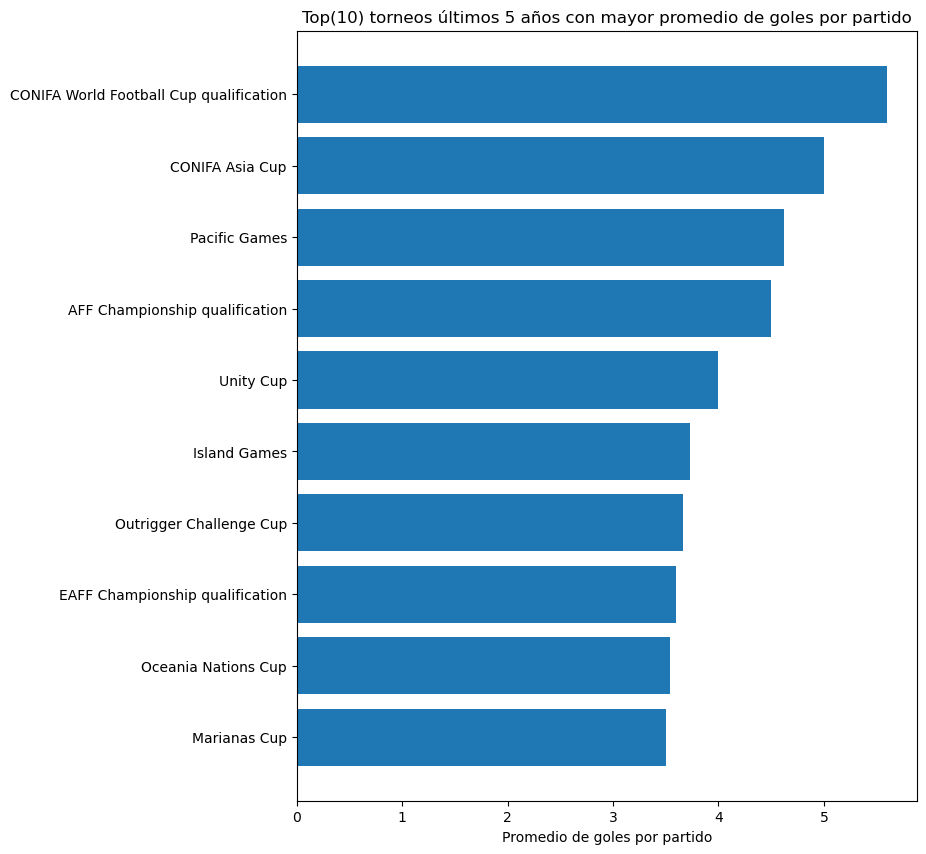

In [155]:
plt.figure(figsize=(8,10))
plt.barh(avg_goals_per_tournament_5y['tournament'], avg_goals_per_tournament_5y['avg_goals_per_match'])
plt.xlabel('Promedio de goles por partido')
plt.title('Top(10) torneos últimos 5 años con mayor promedio de goles por partido')
plt.gca().invert_yaxis()
plt.show()

- Se observa que torneos como CONIFA World Football Cup qualification y CONIFA Asia Cup presentan los promedios más altos de goles por partido (alrededor de 5–5.6), lo que indica que en esos contextos los encuentros suelen ser más abiertos y con más anotaciones.


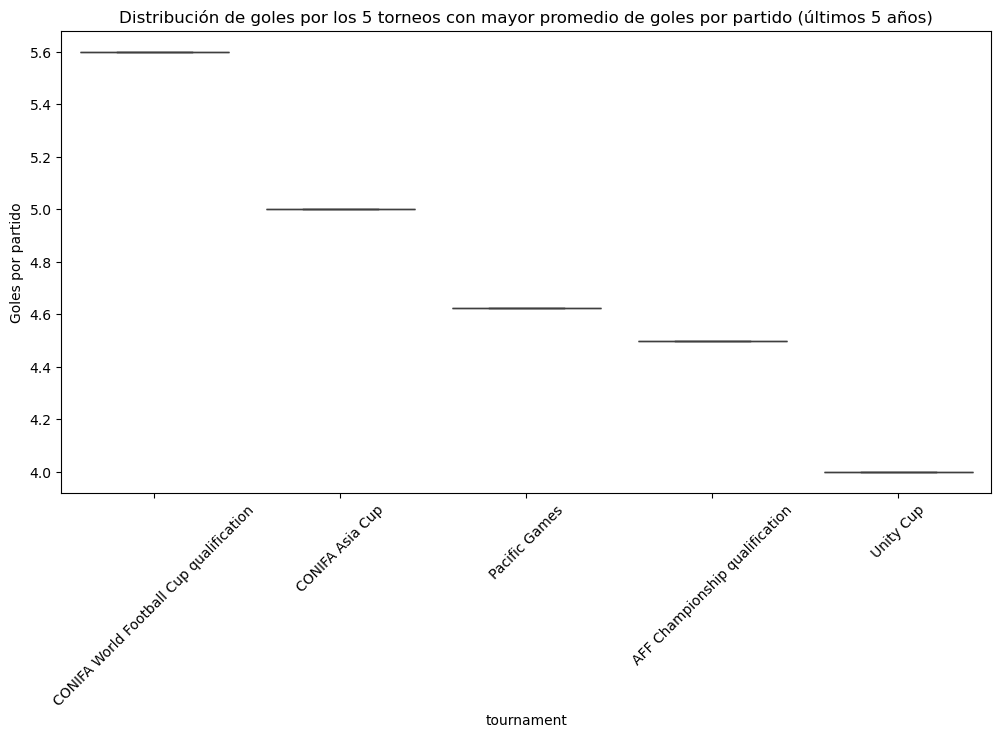

In [160]:
import seaborn as sns

plt.figure(figsize=(12,6))
sns.boxplot(x='tournament', y='avg_goals_per_match', data=goals_per_tournament_5y.head(5))
plt.xticks(rotation=45)
plt.ylabel('Goles por partido')
plt.title('Distribución de goles por los 5 torneos con mayor promedio de goles por partido (últimos 5 años)')
plt.show()

### **Pregunta 3: ¿Cuál es el Top 20 de Jugadores con mayor marcador de goles en diferentes torneos durante los últimos 5 años?**

In [260]:
result_ultimos_5y = ultimos_5y.copy()
result_ultimos_5y

,date,home_team,away_team,home_score,away_score,tournament,city,country,neutral,total_goals
43686,2021-01-12,United Arab Emirates,Iraq,0,0,Friendly,Dubai,United Arab Emirates,False,0
43687,2021-01-18,Kuwait,Palestine,0,1,Friendly,Kuwait City,Kuwait,False,1
43688,2021-01-19,Dominican Republic,Puerto Rico,0,1,Friendly,Santo Domingo,Dominican Republic,False,1
43689,2021-01-22,Guatemala,Puerto Rico,1,0,Friendly,Guatemala City,Guatemala,False,1
43690,2021-01-25,Dominican Republic,Serbia,0,0,Friendly,Santo Domingo,Dominican Republic,False,0
...,...,...,...,...,...,...,...,...,...,...
49282,2026-06-27,Jordan,Argentina,0,0,FIFA World Cup,Arlington,United States,True,0
49283,2026-06-27,Colombia,Portugal,0,0,FIFA World Cup,Miami Gardens,United States,True,0
49284,2026-06-27,DR Congo,Uzbekistan,0,0,FIFA World Cup,Atlanta,United States,True,0
49285,2026-06-27,Panama,England,0,0,FIFA World Cup,East Rutherford,United States,True,0


In [261]:
result_ultimos_dp = result_ultimos_5y.duplicated(
    subset=['date','home_team','away_team'], keep=False
)

# Contar cuántos duplicados hay
num_duplicados = result_ultimos_dp.sum()
print("Número de partidos duplicados:", num_duplicados)

Número de partidos duplicados: 0


In [262]:
goals_ultimos_5y = goals_f[goals_f['date'] >= '2021-01-01'].copy()
goals_ultimos_5y

,date,home_team,away_team,team,scorer,minute,own_goal,penalty
40068,2021-03-24,Antigua and Barbuda,Montserrat,Montserrat,Lyle Taylor,7.0,False,True
40069,2021-03-24,Antigua and Barbuda,Montserrat,Antigua and Barbuda,Eugene Kirwan,23.0,False,False
40070,2021-03-24,Antigua and Barbuda,Montserrat,Montserrat,Lyle Taylor,26.0,False,False
40071,2021-03-24,Antigua and Barbuda,Montserrat,Antigua and Barbuda,D'Andre Bishop,45.0,False,False
40072,2021-03-24,Belgium,Wales,Wales,Harry Wilson,11.0,False,False
...,...,...,...,...,...,...,...,...
47596,2026-03-31,Sweden,Poland,Sweden,Anthony Elanga,20.0,False,False
47597,2026-03-31,Sweden,Poland,Poland,Nicola Zalewski,33.0,False,False
47598,2026-03-31,Sweden,Poland,Sweden,Gustaf Lagerbielke,44.0,False,False
47599,2026-03-31,Sweden,Poland,Poland,Karol Świderski,55.0,False,False


In [263]:
goals_ultimos_dp = goals_ultimos_5y.duplicated(
    subset=['date','home_team','away_team', 'scorer', 'minute'], keep=False
)

# Contar cuántos duplicados hay
num_duplicados = goals_ultimos_dp.sum()
print("Número de partidos duplicados:", num_duplicados)

Número de partidos duplicados: 2


In [264]:
goals_ultimos_5y = goals_ultimos_5y.drop_duplicates(
    subset=['date','home_team','away_team','scorer','minute'],
    keep='first'
)

Calcular goles por jugador dentro del top20

In [284]:
top20_scorers = (
    goals_ultimos_5y.groupby(['date','home_team','away_team','scorer'])
    .size()
    .reset_index(name='goles')
    .sort_values('goles', ascending=False)
    .head(20)
)

In [285]:
top20_scorers.sort_values('goles', ascending=False)

,date,home_team,away_team,scorer,goles
312,2021-05-28,Japan,Myanmar,Yuya Osako,5
6013,2025-09-09,Norway,Moldova,Erling Haaland,5
6119,2025-10-10,Gambia,Gabon,Pierre-Emerick Aubameyang,4
6072,2025-10-09,Austria,San Marino,Marko Arnautović,4
3325,2023-11-16,Egypt,Djibouti,Mohamed Salah,4
6032,2025-09-09,Venezuela,Colombia,Luis Suárez,4
6017,2025-09-09,Norway,Moldova,Thelo Aasgaard,4
5102,2024-11-19,Sweden,Azerbaijan,Viktor Gyökeres,4
3371,2023-11-16,Qatar,Afghanistan,Almoez Ali,4
1653,2021-11-13,France,Kazakhstan,Kylian Mbappé,4


In [288]:
top_partidos = top20_scorers.merge(
    result_ultimos_5y[['date','home_team','away_team','tournament','country']],
    on=['date','home_team','away_team'],
    how='inner'
)

In [287]:
top_partidos

,date,home_team,away_team,scorer,goles,tournament,country
0,2021-05-28,Japan,Myanmar,Yuya Osako,5,FIFA World Cup qualification,Japan
1,2025-09-09,Norway,Moldova,Erling Haaland,5,FIFA World Cup qualification,Norway
2,2021-09-02,Algeria,Djibouti,Islam Slimani,4,FIFA World Cup qualification,Algeria
3,2021-11-15,San Marino,England,Harry Kane,4,FIFA World Cup qualification,San Marino
4,2021-06-05,Turks and Caicos Islands,Haiti,Duckens Nazon,4,FIFA World Cup qualification,Turks and Caicos Islands
5,2021-06-05,Panama,Anguilla,Gabriel Torres,4,FIFA World Cup qualification,Panama
6,2023-11-19,Belgium,Azerbaijan,Romelu Lukaku,4,UEFA Euro qualification,Belgium
7,2021-11-13,France,Kazakhstan,Kylian Mbappé,4,FIFA World Cup qualification,France
8,2025-10-10,Gambia,Gabon,Pierre-Emerick Aubameyang,4,FIFA World Cup qualification,Kenya
9,2024-11-19,Sweden,Azerbaijan,Viktor Gyökeres,4,UEFA Nations League,Sweden


### **Conclusión:**
 la mayoría de los goles por partido se concentran en un rango estrecho, pero existen actuaciones extraordinarias que sobresalen como valores atípicos. Esto ayuda a diferenciar entre jugadores consistentes y aquellos que tienen picos de rendimiento muy altos.

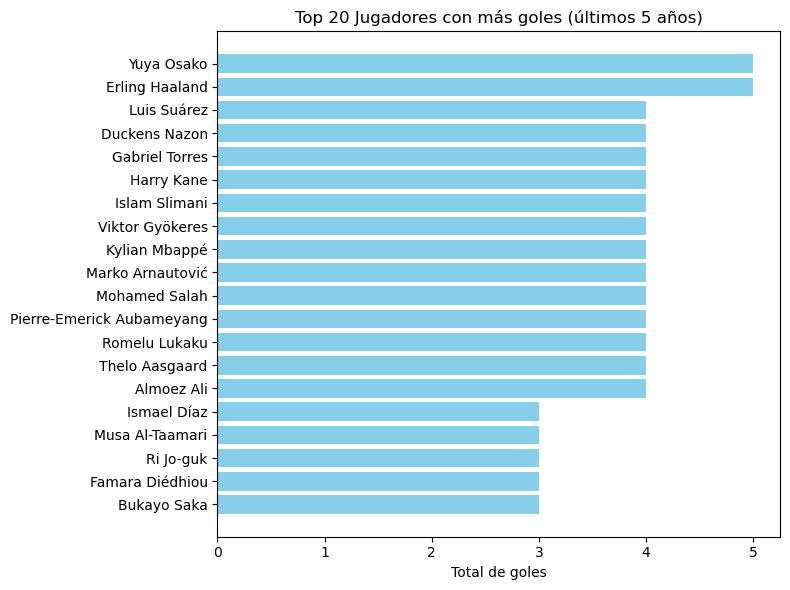

In [298]:
import matplotlib.pyplot as plt

# Agrupar por jugador y sumar goles
goles_por_jugador = (
    top_partidos.groupby('scorer')['goles']
    .sum()
    .reset_index()
    .sort_values('goles', ascending=True)  # orden ascendente para barh
)

plt.figure(figsize=(8,6))
plt.barh(goles_por_jugador['scorer'], goles_por_jugador['goles'], color='skyblue')
plt.xlabel("Total de goles")
plt.title("Top 20 Jugadores con más goles (últimos 5 años)")
plt.tight_layout()
plt.show()

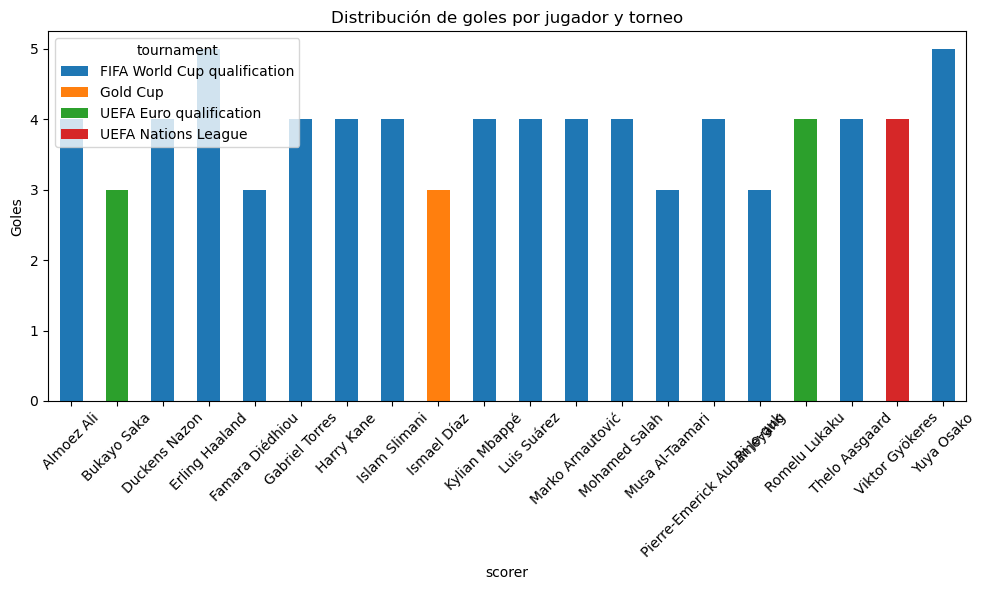

In [297]:
goles_jugador_torneo = (
    top_partidos.groupby(['scorer','tournament'])['goles']
    .sum()
    .unstack(fill_value=0)
)

goles_jugador_torneo.plot(kind='bar', stacked=True, figsize=(10,6))
plt.ylabel("Goles")
plt.title("Distribución de goles por jugador y torneo")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()